## **Classification task: Classical Classification on CIFAR-10**

In [6]:
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!tar -xvzf cifar-10-python.tar.gz

--2026-02-26 14:35:55--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz.1’

cifar-10-python.tar 100%[===================>] 162.60M  53.7MB/s    in 3.2s    

2026-02-26 14:35:59 (51.0 MB/s) - ‘cifar-10-python.tar.gz.1’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


In [7]:
import pickle
import numpy as np
import os

def unpickle(file):
    """ Standard function to load binary batch files. """
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

# 1. Automatic path detection
# This will point to the folder where your notebook is located
current_dir = os.getcwd()
data_dir = '/content/cifar-10-batches-py'

# 2. Check if the directory actually exists before loading
if not os.path.exists(data_dir):
    print(f"Error: The directory {data_dir} was not found!")
    print("Please make sure the folder 'cifar-10-batches-py' is in the same location as this notebook.")
else:
    # 3. Load the first training batch
    file_path = os.path.join(data_dir, 'data_batch_1')
    batch1 = unpickle(file_path)

    # 4. Extract and Reshape
    X_batch = batch1[b'data']
    y_batch = np.array(batch1[b'labels'])

    # Reshape to (N, 3, 32, 32) and then transpose to (N, 32, 32, 3)
    X_batch = X_batch.reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1)

    print(f"Success! Loaded {X_batch.shape[0]} images.")
    print(f"Image shape: {X_batch.shape[1:]} (Width x Height x Channels)")

Success! Loaded 10000 images.
Image shape: (32, 32, 3) (Width x Height x Channels)


**Baseline Models**

Data Preprocessing & Preparation

In [8]:
# 1. Flatten the images: from (10000, 32, 32, 3) to (10000, 3072)
X_flatten = X_batch.reshape(X_batch.shape[0], -1)

# 2. Normalize the pixel values to range [0, 1]
X_normalized = X_flatten.astype('float32') / 255.0

# 3. Use the labels as they are
y_labels = y_batch

print(f"Data is ready for training.")
print(f"Original shape: {X_batch.shape}")
print(f"Flattened shape: {X_normalized.shape}")

Data is ready for training.
Original shape: (10000, 32, 32, 3)
Flattened shape: (10000, 3072)


 Multiclass Logistic Regression (Softmax)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Define the model using Multinomial (Softmax)
# 'lbfgs' is a popular optimizer that supports multiclass classification
softmax_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# 2. Train the model on our normalized batch
softmax_model.fit(X_normalized, y_labels)

# 3. Make predictions
y_pred = softmax_model.predict(X_normalized)

# 4. Evaluate the performance
accuracy = accuracy_score(y_labels, y_pred)
print(f"Softmax Logistic Regression Accuracy: {accuracy * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Softmax Logistic Regression Accuracy: 67.12%


Linear Support Vector Machine (SVM)

In [10]:
from sklearn.svm import LinearSVC

# Define the Linear SVM model
# We use dual=False because we have more samples than features
svm_model = LinearSVC(dual=False, max_iter=1000, verbose=1)

# Train the model on the full normalized batch
svm_model.fit(X_normalized, y_labels)

# Predict and Evaluate
y_pred_svm = svm_model.predict(X_normalized)
acc_svm = accuracy_score(y_labels, y_pred_svm)

print(f"Linear SVM Accuracy: {acc_svm * 100:.2f}%")

[LibLinear]Linear SVM Accuracy: 77.98%


K-Nearest Neighbors (KNN)

In [11]:
from sklearn.neighbors import KNeighborsClassifier

# Define the KNN model with k=5 neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# Training is almost instant for KNN
knn_model.fit(X_normalized, y_labels)

# Predicting on a sample to get a quick result
# KNN prediction is computationally expensive on large datasets
y_pred_knn = knn_model.predict(X_normalized[:500])
acc_knn = accuracy_score(y_labels[:500], y_pred_knn)

print(f"K-Nearest Neighbors (KNN) Accuracy on sample: {acc_knn * 100:.2f}%")

K-Nearest Neighbors (KNN) Accuracy on sample: 45.80%


 **Hyperparameter Selection**





Hyperparameter Selection - Softmax (Regularization C)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 0.01, accuracy = 0.4770


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 0.1, accuracy = 0.6350


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'mul

C = 1, accuracy = 0.8180


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C = 10, accuracy = 0.8360


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C = 100, accuracy = 0.8350


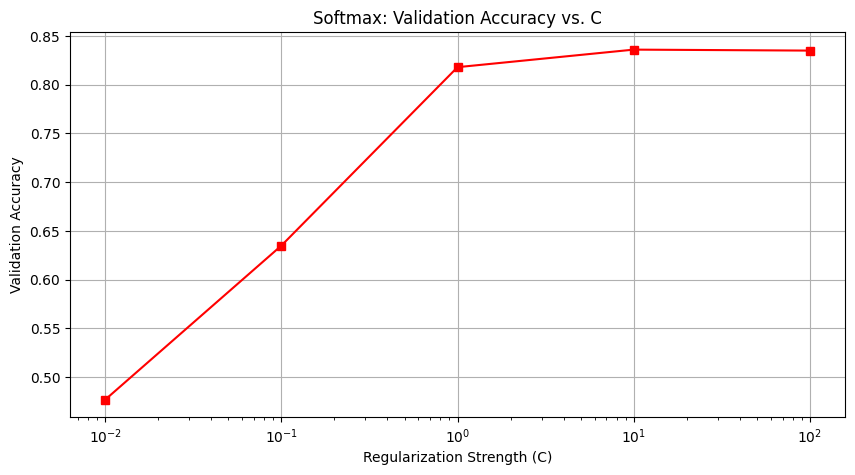

In [12]:
import matplotlib.pyplot as plt
c_values = [0.01, 0.1, 1, 10, 100]
softmax_accuracies = []

for c in c_values:
    # Using a smaller max_iter for speed during selection
    model = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=c, max_iter=500)
    model.fit(X_normalized[:5000], y_labels[:5000]) # Sample for speed
    acc = accuracy_score(y_labels[:1000], model.predict(X_normalized[:1000]))
    softmax_accuracies.append(acc)
    print(f"C = {c}, accuracy = {acc:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(c_values, softmax_accuracies, marker='s', color='red')
plt.xscale('log') # Log scale is better for C values
plt.title('Softmax: Validation Accuracy vs. C')
plt.xlabel('Regularization Strength (C)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()


Hyperparameter Selection - Linear SVM

SVM C=0.01: Accuracy = 0.3580
SVM C=0.1: Accuracy = 0.2970
SVM C=1: Accuracy = 0.2590
SVM C=10: Accuracy = 0.2300
SVM C=100: Accuracy = 0.2140


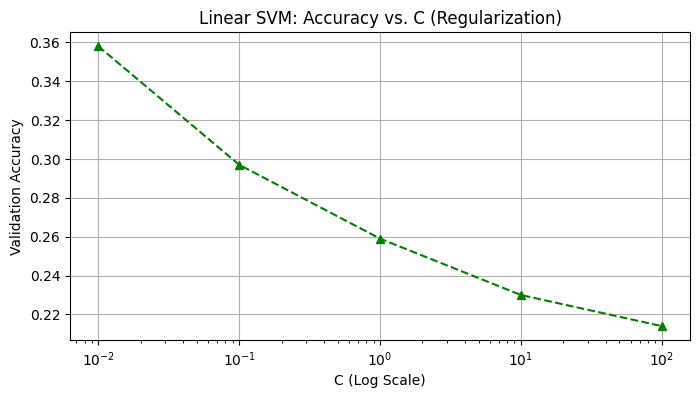

In [13]:
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Defining the missing variables for this cell
c_values = [0.01, 0.1, 1, 10, 100]
svm_accs = []

for c in c_values:
    # Training on 5,000 samples and validating on 1,000 for selection
    model = LinearSVC(dual=False, C=c, max_iter=1000)
    model.fit(X_normalized[:5000], y_labels[:5000])
    acc = accuracy_score(y_labels[5000:6000], model.predict(X_normalized[5000:6000]))
    svm_accs.append(acc)
    print(f"SVM C={c}: Accuracy = {acc:.4f}")

# Plotting the Support Vector Machine results
plt.figure(figsize=(8, 4))
plt.plot(c_values, svm_accs, marker='^', color='green', linestyle='--')
plt.xscale('log')
plt.title('Linear SVM: Accuracy vs. C (Regularization)')
plt.xlabel('C (Log Scale)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

Hyperparameter Selection - KNN (Number of Neighbors k)

k = 1, accuracy = 1.0000
k = 3, accuracy = 0.5280
k = 5, accuracy = 0.4580
k = 8, accuracy = 0.4240
k = 10, accuracy = 0.4000
k = 12, accuracy = 0.3620
k = 15, accuracy = 0.3400
k = 20, accuracy = 0.3200


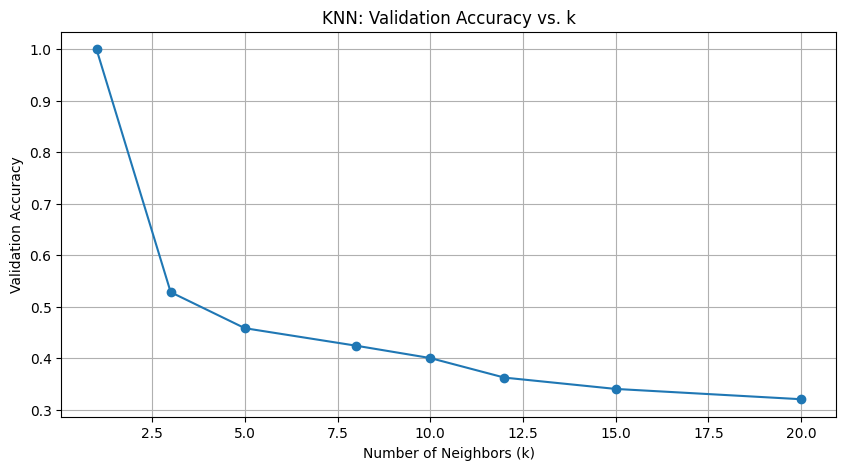

In [14]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
k_choices = [1, 3, 5, 8, 10, 12, 15, 20]
k_accuracies = []

for k in k_choices:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_normalized, y_labels)
    # Testing on a sample for efficiency
    y_pred_k = knn.predict(X_normalized[:500])
    acc = accuracy_score(y_labels[:500], y_pred_k)
    k_accuracies.append(acc)
    print(f"k = {k}, accuracy = {acc:.4f}")

# Plotting the results as required
plt.figure(figsize=(10, 5))
plt.plot(k_choices, k_accuracies, marker='o')
plt.title('KNN: Validation Accuracy vs. k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

Evaluation and Analysis

--- FINAL EVALUATION ---
Final Model (Softmax) Test Accuracy: 0.3327


<Figure size 1000x800 with 0 Axes>

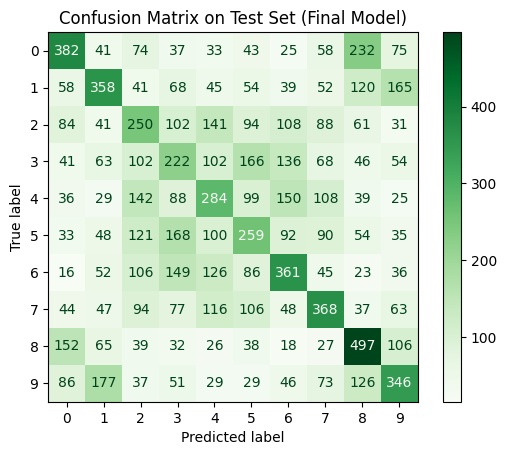

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# 1. Loading the Test Set (as required by the instructions)
test_batch = unpickle(os.path.join(data_dir, 'test_batch'))
X_test = test_batch[b'data'].reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1).reshape(10000, -1) / 255.0
y_test = np.array(test_batch[b'labels'])

# 2. Final Evaluation on Test Set
# Assuming Softmax was your best model
y_test_pred = softmax_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"--- FINAL EVALUATION ---")
print(f"Final Model (Softmax) Test Accuracy: {test_acc:.4f}")

# 3. Final Confusion Matrix for the Report
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix on Test Set (Final Model)')
plt.show()